# Global Clinical Trial Analytics Dashboard

This dashboard summarizes key business insights extracted from global clinical trial data using SQL and Python visualization.

The analysis focuses on trial volume, treatment areas, sponsor activity, enrollment patterns, and phase-specific risks.

 - SQL - Q1 Which pharmaceutical companies are the most active?
 - SQL - Q2 Which therapeutic areas are the most popular?
 - SQL - Q3 Which phase has the highest failure rate?
 - SQL - Q4 Which sponsors conduct the largest trials?
 - SQL - Q5 What is the average number of participants recruited per phase?
 - SQL - Q6 Which phase recruits the most participants overall?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/clean/clinical_trials_clean.csv")

In [3]:
total_trials = len(df)

total_sponsors = df["Sponsor"].nunique()

total_conditions = df["Condition"].nunique()

total_enrollment = int(df["Enrollment"].sum())

print("Total Trials:", total_trials)
print("Total Sponsors:", total_sponsors)
print("Total Conditions:", total_conditions)
print("Total Enrollment:", total_enrollment)

Total Trials: 13485
Total Sponsors: 10
Total Conditions: 852
Total Enrollment: 5820807


## Q1 - Top10 Sponsors

In [4]:
# Q1 - Top10 Sponsors
top_sponsors = (
    df["Sponsor"].value_counts().head(10)   #.value_counts() --> calculate the total number
)

top_sponsors

Sponsor
GSK         2414
Novartis    2303
Pfizer      1939
Merck       1758
Sanofi      1512
Roche       1068
JNJ         1067
Bayer        594
AbbVie       417
Gilead       413
Name: count, dtype: int64

In [5]:
import matplotlib.pyplot as plt

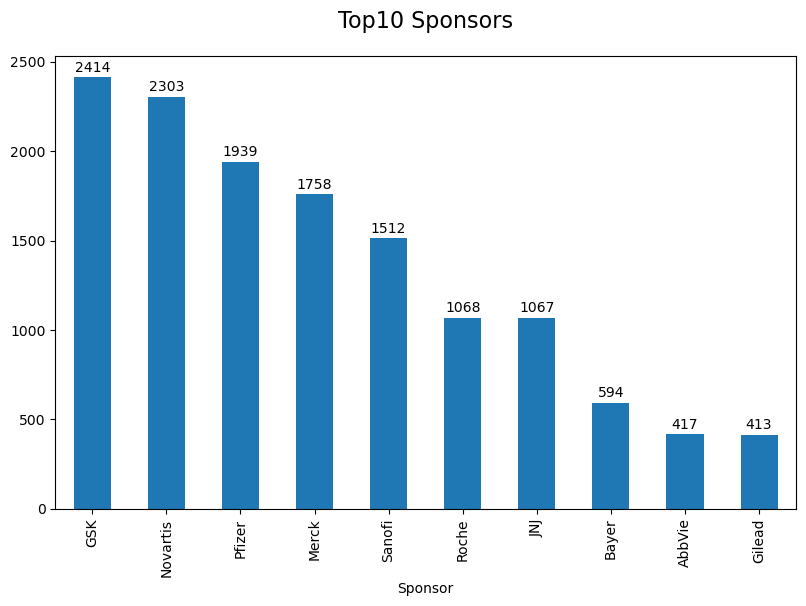

In [6]:
plt.figure(figsize=(8, 6))
ax = top_sponsors.plot(kind="bar")
plt.title("Top10 Sponsors", fontsize=16, pad=20)
plt.bar_label(ax.containers[0], padding=2)
plt.tight_layout(pad=0.5)
plt.show()

## Q2 - Most Popular Treatment Areas (Top 10 Disease Areas)

In [7]:
top_conditions = df["Condition"].value_counts().head(10)

top_conditions

Condition
Diabetes Mellitus, Type 2                 529
Breast Neoplasms                          388
Hypertension                              338
Pulmonary Disease, Chronic Obstructive    336
Asthma                                    331
Arthritis, Rheumatoid                     329
Influenza, Human                          323
Schizophrenia                             290
Diabetes Mellitus                         262
Alzheimer Disease                         214
Name: count, dtype: int64

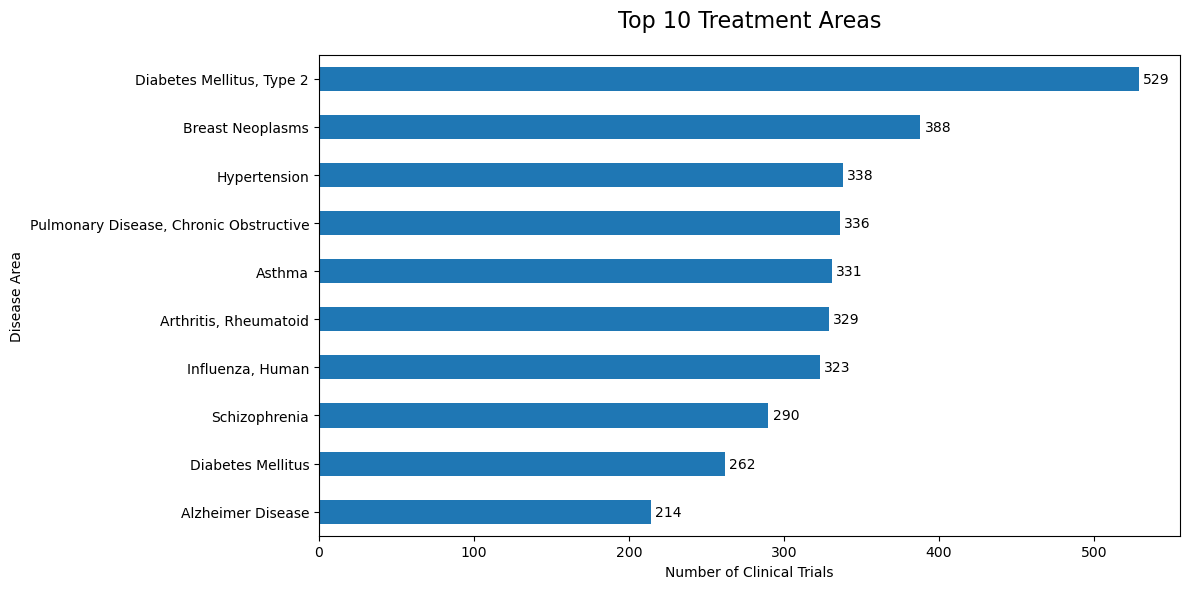

In [69]:
plt.figure(figsize=(12,6))

ax = top_conditions.sort_values().plot(kind="barh")

plt.title("Top 10 Treatment Areas", fontsize=16, pad=20)

plt.xlabel("Number of Clinical Trials")
plt.ylabel("Disease Area")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

## Key Findings - From Q2

- Type 2 Diabetes is the most frequently studied disease area, with over 500 registered clinical trials.
- Oncology-related research remains highly active, with Breast Neoplasms ranking among the top treatment areas.
- Chronic diseases such as Hypertension, Asthma, and Rheumatoid Arthritis account for a large share of clinical research activity.

## Q3 - Failure Rate by Clinical Trial Phase

In [9]:
phase_total = df.groupby("Phase").size().reset_index(name="total_trials")

phase_total

,Phase,total_trials
0,Early Phase 1,10
1,Phase 1,2516
2,Phase 1/Phase 2,322
3,Phase 2,3596
4,Phase 2/Phase 3,139
5,Phase 3,4887
6,Phase 4,2015


In [10]:
failed_trials = df[df["Status"].isin(["Terminated","Withdrawn"])]

failed_trials.shape

(1551, 10)

In [11]:
phase_failed = failed_trials.groupby("Phase").size().reset_index(name="failed_trials")

phase_failed

,Phase,failed_trials
0,Phase 1,247
1,Phase 1/Phase 2,45
2,Phase 2,554
3,Phase 2/Phase 3,24
4,Phase 3,444
5,Phase 4,237


In [12]:
failure_rate = pd.merge(
    phase_total,
    phase_failed,
    on="Phase",  # merge according to "Phase"
    how="left"  # merge method left connection
)

failure_rate

,Phase,total_trials,failed_trials
0,Early Phase 1,10,NaN
1,Phase 1,2516,247.0
2,Phase 1/Phase 2,322,45.0
3,Phase 2,3596,554.0
4,Phase 2/Phase 3,139,24.0
5,Phase 3,4887,444.0
6,Phase 4,2015,237.0


In [13]:
failure_rate["failed_trials"] = (
    failure_rate["failed_trials"].fillna(0)
)

failure_rate

,Phase,total_trials,failed_trials
0,Early Phase 1,10,0.0
1,Phase 1,2516,247.0
2,Phase 1/Phase 2,322,45.0
3,Phase 2,3596,554.0
4,Phase 2/Phase 3,139,24.0
5,Phase 3,4887,444.0
6,Phase 4,2015,237.0


In [14]:
failure_rate["failure_rate"] = (
    100 * failure_rate["failed_trials"] / failure_rate["total_trials"]
).round(2)

failure_rate

,Phase,total_trials,failed_trials,failure_rate
0,Early Phase 1,10,0.0,0.00
1,Phase 1,2516,247.0,9.82
2,Phase 1/Phase 2,322,45.0,13.98
3,Phase 2,3596,554.0,15.41
4,Phase 2/Phase 3,139,24.0,17.27
5,Phase 3,4887,444.0,9.09
6,Phase 4,2015,237.0,11.76


In [15]:
failure_rate = (
    failure_rate.sort_values("failure_rate", ascending=False)
)

failure_rate

,Phase,total_trials,failed_trials,failure_rate
4,Phase 2/Phase 3,139,24.0,17.27
3,Phase 2,3596,554.0,15.41
2,Phase 1/Phase 2,322,45.0,13.98
6,Phase 4,2015,237.0,11.76
1,Phase 1,2516,247.0,9.82
5,Phase 3,4887,444.0,9.09
0,Early Phase 1,10,0.0,0.00


In [16]:
for i, value in enumerate(failure_rate["failure_rate"]):
    print(i, value)

0 17.27
1 15.41
2 13.98
3 11.76
4 9.82
5 9.09
6 0.0


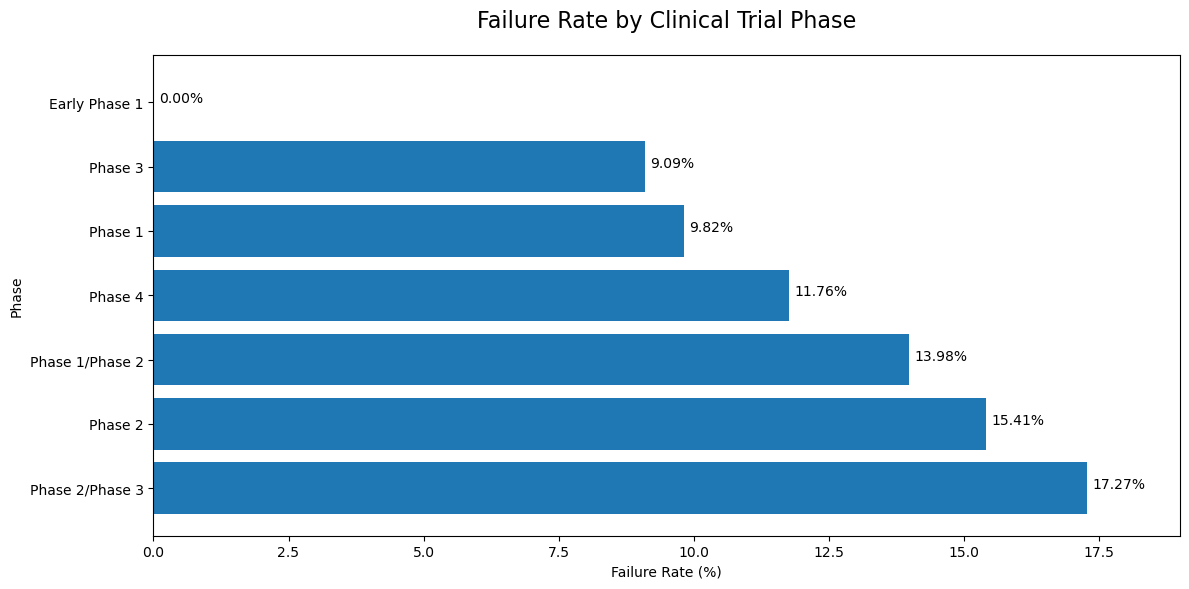

In [74]:
fig, ax = plt.subplots(figsize=(12,6))
ax.barh(failure_rate["Phase"],failure_rate["failure_rate"])

plt.title("Failure Rate by Clinical Trial Phase", fontsize=16, pad=20)
plt.xlabel("Failure Rate (%)")
plt.ylabel("Phase")

for i, value in enumerate(failure_rate["failure_rate"]):
    ax.text(value+0.1,i,f"{value:.2f}%")

ax.set_xlim(0, failure_rate["failure_rate"].max()*1.1)

plt.tight_layout()
plt.show()

## Key Findings - From Q3

- Phase 2/Phase 3 studies exhibit the highest failure rate (17.27%), followed by Phase 2 studies (15.41%).
- Failure rates tend to decrease in later-stage trials, with Phase 3 showing a lower failure rate than expected.
- The results suggest that many clinical programs are discontinued during efficacy validation, particularly in Phase 2.
- Early Phase 1 studies show no recorded failures in this dataset, although the sample size is very small.

## Q4 - Top Sponsors by Total Enrollment

In [25]:
sponsor_enrollment = df.groupby("Sponsor")["Enrollment"].sum().sort_values(ascending=False).head(10)

sponsor_enrollment

Sponsor
GSK         1253148
Merck        924211
Novartis     860803
Sanofi       850287
Pfizer       765447
Roche        344416
JNJ          334240
Bayer        278919
AbbVie       109007
Gilead       100329
Name: Enrollment, dtype: int64

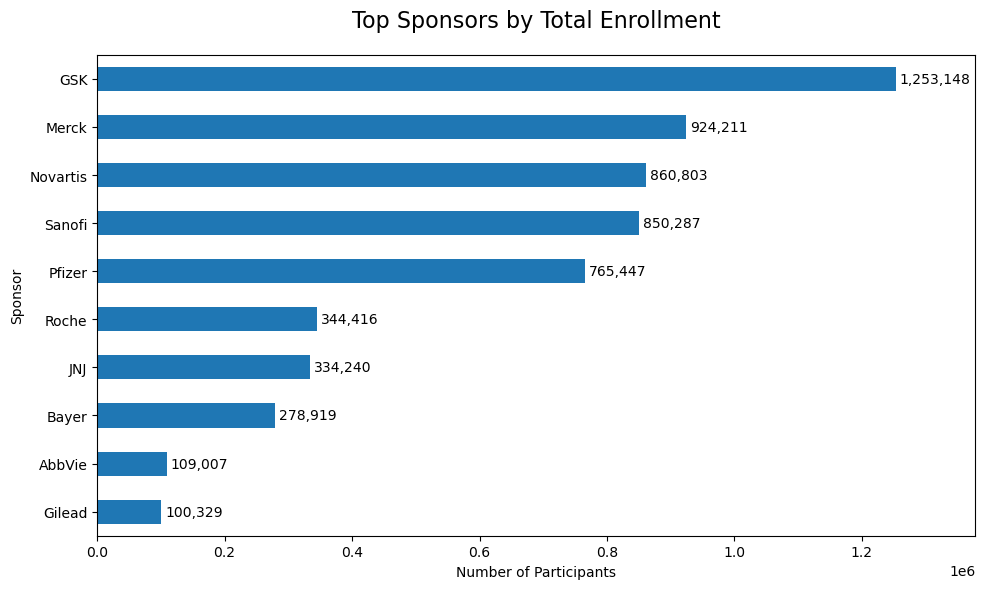

In [67]:
fig, ax = plt.subplots(figsize=(10,6))

sponsor_enrollment.plot(kind='barh', ax=ax)
ax.invert_yaxis()

plt.title("Top Sponsors by Total Enrollment", fontsize=16, pad=20)
plt.xlabel("Number of Participants")
plt.ylabel("Sponsor")

labels = [f"{v:,.0f}" for v in sponsor_enrollment.values]
ax.bar_label(ax.containers[0], labels = labels, padding=3)

ax.set_xlim(0, max(sponsor_enrollment.values)*1.1)

plt.tight_layout()
plt.show()

### Key Findings - From Q4

- GSK conducted the largest clinical trial programs, enrolling more than 1.25 million participants across all registered studies.
- Merck, Novartis, and Sanofi also managed large-scale trial portfolios, each enrolling more than 850,000 participants.
- Enrollment volume is not perfectly aligned with trial count, indicating that some sponsors tend to conduct larger studies rather than simply more studies.
- The results suggest substantial differences in research scale and participant reach among major pharmaceutical companies.

## Q5 - Average Enrollment By Phase

In [29]:
phase_avg = (
    df.groupby("Phase")["Enrollment"].mean().sort_values(ascending=False)
)

phase_avg

Phase
Phase 3            795.794762
Phase 2/Phase 3    565.697842
Phase 4            518.169231
Phase 2            180.114850
Phase 1/Phase 2     99.860248
Early Phase 1       58.200000
Phase 1             51.106916
Name: Enrollment, dtype: float64

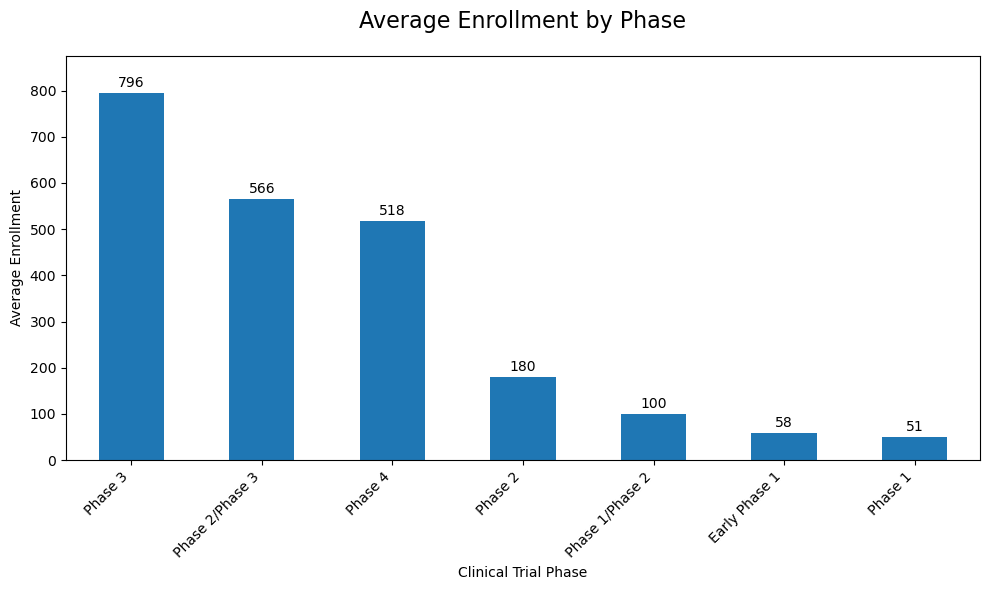

In [42]:
plt.figure(figsize=(10,6))

ax = phase_avg.plot(kind="bar")

plt.title("Average Enrollment by Phase", fontsize=16, pad=20)
plt.xlabel("Clinical Trial Phase")
plt.ylabel("Average Enrollment")

labels = [f"{v:,.0f}" for v in phase_avg.values]
ax.bar_label(ax.containers[0], labels = labels, padding=2)

ax.tick_params(axis='x', rotation=45)
ax.set_xticklabels(ax.get_xticklabels(), ha='right')
ax.set_ylim(0, max(phase_avg.values)*1.1)

plt.tight_layout()
plt.show()

### Key Finding - From Q5

- Phase 3 trials have the highest average enrollment (round 796 participants).
- Phase 2/3 and Phase 4 studies also involve relatively large participant groups.
- Early Phase 1 and Phase 1 trials have the smallest average enrollment sizes.
- Trial size generally increases as studies progress to later clinical phases.

## Q6 - Enrollment Distribution by Phase

In [62]:
phase_total = (
    df.groupby("Phase")["Enrollment"].sum().sort_values(ascending=True)
)

phase_total

Phase
Early Phase 1          582
Phase 1/Phase 2      32155
Phase 2/Phase 3      78632
Phase 1             128585
Phase 2             647693
Phase 4            1044111
Phase 3            3889049
Name: Enrollment, dtype: int64

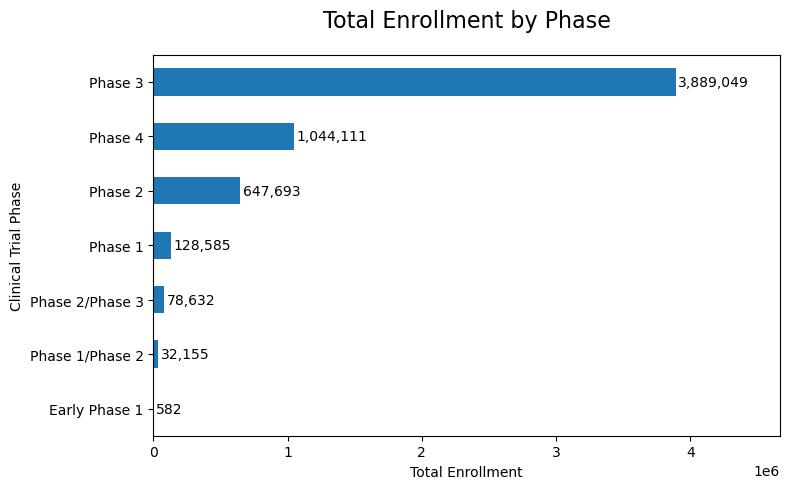

In [63]:
fig, ax = plt.subplots(figsize=(8,5))

phase_total.plot(kind='barh', ax=ax)

plt.title("Total Enrollment by Phase", fontsize=16, pad=20)
plt.xlabel("Total Enrollment")
plt.ylabel("Clinical Trial Phase")

labels = [f"{v:,.0f}" for v in phase_total.values]
ax.bar_label(ax.containers[0], labels=labels, padding=2)

ax.set_xlim(0, max(phase_total.values)*1.2)

plt.tight_layout()
plt.show()

### Key Findings - From Q6

- Phase 3 trials enrolled the largest number of participants, with nearly 3.9 million subjects across all studies.
- Phase 4 ranked second, contributing more than 1 million enrolled participants.
- Early-stage trials (Early Phase 1 and Phase 1) involved substantially fewer participants.
- The majority of participant enrollment occurs during late-stage clinical development, especially in Phase 3 studies.